# 🏠 BƯỚC 3: HUẤN LUYỆN MÔ HÌNH AI
**Dự án:** Dự đoán Giá Bất Động Sản Việt Nam  
**Phụ trách:** Thái (ML Engineer)  
**Mô tả:** Train 4 thuật toán ML bằng `sklearn.Pipeline`, so sánh và xuất model tốt nhất

> **Phiên bản:** Pipeline v2 — sử dụng `ColumnTransformer` + `OneHotEncoder` (chuẩn ML)  
> **Đồng bộ với:** `run_training.py` và `app/app.py`

## 1. Import thư viện

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Load và kết hợp dữ liệu

In [34]:
URL_CC = 'https://raw.githubusercontent.com/tangoctai2004/House-Price-Prediction/refs/heads/main/data/processed/cleaned_chung_cu.csv'
URL_ND = 'https://raw.githubusercontent.com/tangoctai2004/House-Price-Prediction/refs/heads/main/data/processed/cleaned_nha_dat.csv'

df_cc = pd.read_csv('../data/processed/cleaned_chung_cu.csv')
df_nd = pd.read_csv('../data/processed/cleaned_nha_dat.csv')

df_cc['loai_bds'] = 'chung_cu'
df_nd['loai_bds'] = 'nha_dat'

print(f'📦 Chung cư: {df_cc.shape[0]} bản ghi, {df_cc.shape[1]} cột')
print(f'📦 Nhà đất : {df_nd.shape[0]} bản ghi, {df_nd.shape[1]} cột')

📦 Chung cư: 5452 bản ghi, 12 cột
📦 Nhà đất : 6379 bản ghi, 14 cột


## 3. Tiền xử lý và tạo feature chung

In [35]:
# Chung cư không có floors, frontage, road_width -> gán 0
df_cc2 = df_cc.copy()
if 'balcony_direction' in df_cc2.columns:
    df_cc2 = df_cc2.drop(columns=['balcony_direction'])
for c in ['floors_num', 'frontage_m', 'road_width_m']:
    df_cc2[c] = 0

ALL_COLS = ['price_billion','area_m2','bedrooms_num','city','district','direction',
            'furniture_std','legal_std','floors_num','frontage_m','road_width_m','loai_bds']

df_all = pd.concat([df_cc2[ALL_COLS], df_nd[ALL_COLS]], ignore_index=True)
print(f'\n📊 Dataset tổng hợp: {df_all.shape[0]} bản ghi')
print(f'Phân bổ loại BĐS:')
print(df_all['loai_bds'].value_counts())


📊 Dataset tổng hợp: 11831 bản ghi
Phân bổ loại BĐS:
loai_bds
nha_dat     6379
chung_cu    5452
Name: count, dtype: int64


In [36]:
# Làm sạch & lọc outlier
df_all = df_all.dropna(subset=['price_billion','area_m2'])
df_all = df_all[(df_all['price_billion'] >= 1) & (df_all['price_billion'] <= 200)]
df_all = df_all[(df_all['area_m2'] >= 10) & (df_all['area_m2'] <= 1000)]

print(f'✅ Sau khi lọc outlier: {df_all.shape[0]} bản ghi')
print(df_all.describe())

✅ Sau khi lọc outlier: 11786 bản ghi
       price_billion       area_m2  bedrooms_num    floors_num    frontage_m  \
count   11786.000000  11786.000000  11786.000000  11786.000000  11786.000000   
mean       10.224177     75.474880      3.404633      2.134906      2.717097   
std        10.315878     46.623494      2.485722      2.296286      3.576312   
min         1.000000     15.000000      1.000000      0.000000      0.000000   
25%         4.700000     50.000000      2.000000      0.000000      0.000000   
50%         7.300000     67.000000      3.000000      2.000000      3.800000   
75%        11.800000     85.000000      4.000000      4.000000      4.600000   
max       172.000000    935.000000     25.000000     10.000000    200.000000   

       road_width_m  
count  11786.000000  
mean       3.039973  
std        3.882382  
min        0.000000  
25%        0.000000  
50%        3.000000  
75%        5.000000  
max       50.000000  


## 4. Thiết lập Pipeline tiền xử lý (ColumnTransformer)

Thay vì dùng `LabelEncoder` thủ công, ta sử dụng `ColumnTransformer` kết hợp:
- `StandardScaler` cho các biến số (area, bedrooms, floors...)
- `OneHotEncoder` cho các biến phân loại (district, direction, furniture...)

Ưu điểm:
- **Đúng kỹ thuật:** OneHotEncoder không tạo thứ tự giả cho biến Nominal
- **An toàn:** `handle_unknown='ignore'` giúp model không crash khi gặp quận mới
- **Gọn gàng:** Chỉ cần 1 file `.pkl` duy nhất để deploy lên Web

In [37]:
FEATURES = ['area_m2','bedrooms_num','city','district','direction','furniture_std','legal_std',
            'floors_num','frontage_m','road_width_m','loai_bds']
TARGET = 'price_billion'

numeric_features = ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
categorical_features = ['city', 'district', 'direction', 'furniture_std', 'legal_std', 'loai_bds']

# Đảm bảo categorical là string
df_m = df_all.copy()
for c in categorical_features:
    df_m[c] = df_m[c].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print('✅ ColumnTransformer đã thiết lập!')
print(f'  Numeric features  : {numeric_features}')
print(f'  Categorical features: {categorical_features}')

✅ ColumnTransformer đã thiết lập!
  Numeric features  : ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
  Categorical features: ['district', 'direction', 'furniture_std', 'legal_std', 'loai_bds']


## 5. Chia dữ liệu Train / Test (80:20)

In [38]:
X = df_m[FEATURES]
y = df_m[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'🎯 Train: {X_train.shape[0]} mẫu')
print(f'🎯 Test : {X_test.shape[0]} mẫu')
print(f'📐 Số features: {len(FEATURES)}')

🎯 Train: 9428 mẫu
🎯 Test : 2358 mẫu
📐 Số features: 10


## 6. Hàm Train & Đánh giá (với Pipeline)

In [39]:
results = {}

def train_eval(name, base_model, X_tr, X_te, y_tr, y_te):
    """Train model bằng Pipeline (preprocessor + model) và đánh giá."""
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', base_model)
    ])
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'pipeline': pipeline, 'y_pred': y_pred}
    
    print(f'\n{"="*50}')
    print(f'🤖 {name}')
    print(f'  RMSE : {rmse:.4f} tỷ')
    print(f'  MAE  : {mae:.4f} tỷ')
    print(f'  R²   : {r2:.4f} ({r2*100:.1f}%)')

## 7. Train 4 thuật toán ML

In [40]:
print('🔵 [1/4] Linear Regression...')
train_eval('Linear Regression', LinearRegression(), X_train, X_test, y_train, y_test)

🔵 [1/4] Linear Regression...

🤖 Linear Regression
  RMSE : 6.7625 tỷ
  MAE  : 3.5577 tỷ
  R²   : 0.5884 (58.8%)


In [41]:
print('🟡 [2/4] Decision Tree...')
train_eval('Decision Tree',
           DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42),
           X_train, X_test, y_train, y_test)

🟡 [2/4] Decision Tree...

🤖 Decision Tree
  RMSE : 7.3002 tỷ
  MAE  : 3.4185 tỷ
  R²   : 0.5204 (52.0%)


In [42]:
print('🟢 [3/4] Random Forest...')
train_eval('Random Forest',
           RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_split=4, random_state=42, n_jobs=-1),
           X_train, X_test, y_train, y_test)

🟢 [3/4] Random Forest...

🤖 Random Forest
  RMSE : 5.5829 tỷ
  MAE  : 2.7689 tỷ
  R²   : 0.7195 (71.9%)


In [43]:
print('🔴 [4/4] XGBoost...')
train_eval('XGBoost',
           XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, n_jobs=-1, verbosity=0),
           X_train, X_test, y_train, y_test)

🔴 [4/4] XGBoost...

🤖 XGBoost
  RMSE : 4.8809 tỷ
  MAE  : 2.4847 tỷ
  R²   : 0.7856 (78.6%)


## 8. So sánh kết quả 4 mô hình

In [44]:
compare_df = pd.DataFrame({
    name: {'RMSE (tỷ)': v['RMSE'], 'MAE (tỷ)': v['MAE'], 'R² Score': v['R2']}
    for name, v in results.items()
}).T.round(4)

print('\n' + '='*65)
print('📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH')
print('='*65)
print(compare_df.to_string())

best_name = max(results, key=lambda x: results[x]['R2'])
print(f'\n🏆 MODEL TỐT NHẤT: {best_name}  (R² = {results[best_name]["R2"]:.4f})')


📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH
                   RMSE (tỷ)  MAE (tỷ)  R² Score
Linear Regression     6.7625    3.5577    0.5884
Decision Tree         7.3002    3.4185    0.5204
Random Forest         5.5829    2.7689    0.7195
XGBoost               4.8809    2.4847    0.7856

🏆 MODEL TỐT NHẤT: XGBoost  (R² = 0.7856)


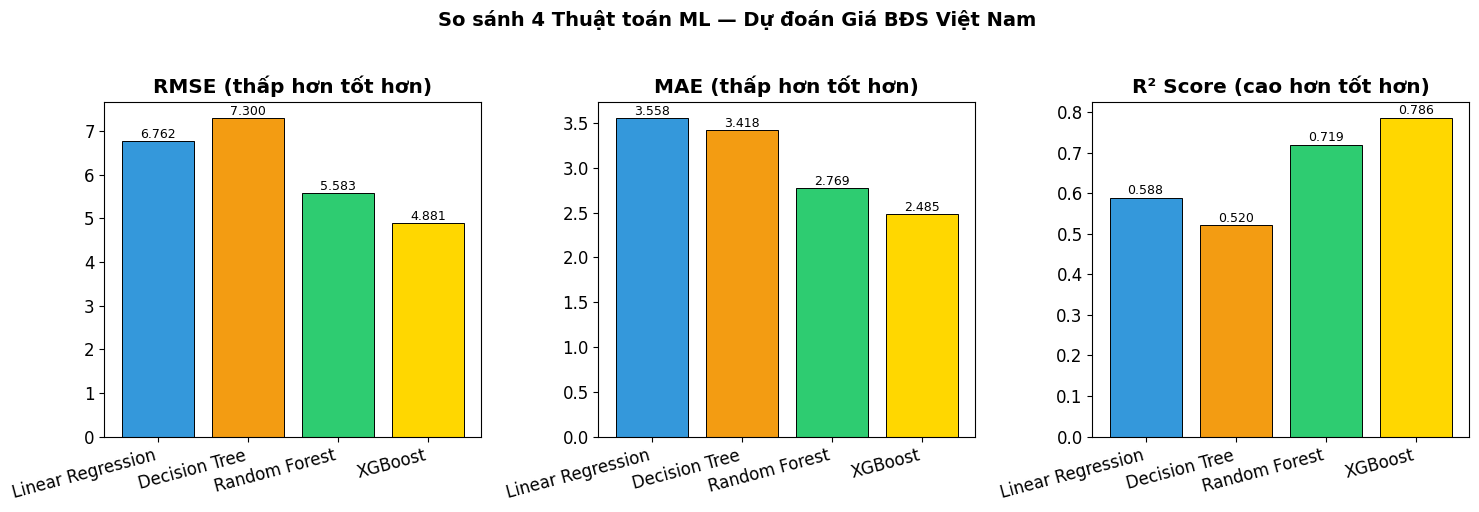

✅ Đã lưu biểu đồ so sánh!


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(results.keys())
colors = ['#3498db','#f39c12','#2ecc71','#e74c3c']

for ax, metric, title, best_fn in zip(
    axes,
    ['RMSE','MAE','R2'],
    ['RMSE (thấp hơn tốt hơn)','MAE (thấp hơn tốt hơn)','R² Score (cao hơn tốt hơn)'],
    [min, min, max]
):
    vals = [results[n][metric] for n in names]
    best_val = best_fn(vals)
    bar_colors = ['gold' if v == best_val else c for v, c in zip(vals, colors)]
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('So sánh 4 Thuật toán ML — Dự đoán Giá BĐS Việt Nam', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ so sánh!')

## 9. Xuất Pipeline tốt nhất (.pkl)

In [46]:
os.makedirs('../models', exist_ok=True)

best_pipeline = results[best_name]['pipeline']

# Lưu pipeline (bao gồm cả preprocessor + model trong 1 file duy nhất)
with open('../models/best_model_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Trích xuất Feature Importance cho XAI (Giải thích AI trên Web)
base_model_best = best_pipeline.named_steps['model']
ohe_cols_best = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feat_names = numeric_features + list(ohe_cols_best)
fi_values = base_model_best.feature_importances_
fi_dict = dict(zip(all_feat_names, [float(v) for v in fi_values]))

# Lưu metadata (bao gồm Feature Importance cho XAI)
model_meta = {
    'best_model_name': best_name,
    'features': FEATURES,
    'target': TARGET,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'metrics': {k: v for k, v in results[best_name].items() if k in ['RMSE','MAE','R2']},
    'all_results': {n: {k: v for k, v in d.items() if k in ['RMSE','MAE','R2']} for n, d in results.items()},
    'feature_importance': fi_dict  # ← THÊM MỚI: Dùng cho XAI trên Web
}
with open('../models/model_meta.pkl', 'wb') as f:
    pickle.dump(model_meta, f)

print('✅ Đã xuất các file:')
print('   📁 models/best_model_pipeline.pkl — Pipeline hoàn chỉnh (preprocessor + model)')
print('   📁 models/model_meta.pkl          — Metadata, kết quả & Feature Importance (XAI)')
print('   📁 models/model_comparison.png    — Biểu đồ so sánh')
print(f'\n🏆 Model xuất: {best_name}')
print(f'📊 Feature Importance đã được lưu ({len(fi_dict)} features) → Dùng cho Giải thích AI trên Web')
print(f'\n💡 Lưu ý: Chỉ cần 1 file pipeline.pkl duy nhất để deploy lên Web!')
print(f'   Web chỉ cần gọi: pipeline.predict(raw_dataframe) — không cần encode/scale thủ công.')


✅ Đã xuất các file:
   📁 models/best_model_pipeline.pkl — Pipeline hoàn chỉnh (preprocessor + model)
   📁 models/model_meta.pkl          — Metadata, kết quả & Feature Importance (XAI)
   📁 models/model_comparison.png    — Biểu đồ so sánh

🏆 Model xuất: XGBoost
📊 Feature Importance đã được lưu (68 features) → Dùng cho Giải thích AI trên Web

💡 Lưu ý: Chỉ cần 1 file pipeline.pkl duy nhất để deploy lên Web!
   Web chỉ cần gọi: pipeline.predict(raw_dataframe) — không cần encode/scale thủ công.


## 10. Feature Importance (Random Forest & XGBoost)

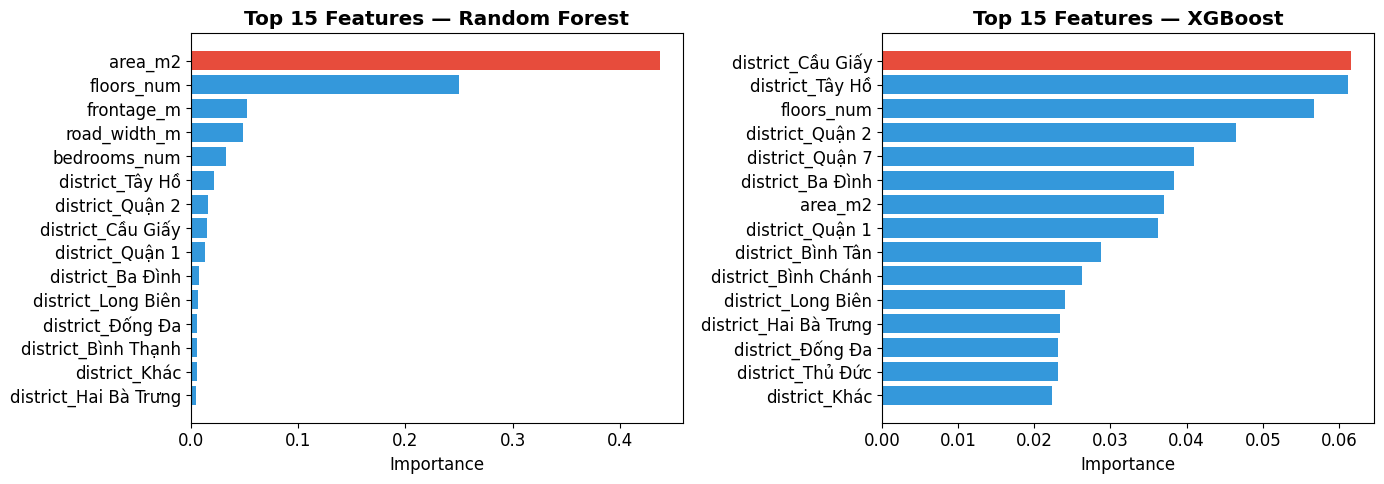

✅ Đã lưu biểu đồ Feature Importance!


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in [(axes[0], 'Random Forest'), (axes[1], 'XGBoost')]:
    pipeline = results[model_name]['pipeline']
    base_model = pipeline.named_steps['model']
    
    # Lấy feature names sau OneHotEncoder
    ohe_cols = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = numeric_features + list(ohe_cols)
    
    fi = base_model.feature_importances_
    fi_df = pd.DataFrame({'feature': all_features, 'importance': fi})\
              .sort_values('importance', ascending=False).head(15)
    fi_df = fi_df.sort_values('importance', ascending=True)
    
    colors_fi = ['#e74c3c' if i == fi_df['importance'].idxmax() else '#3498db'
                 for i in fi_df.index]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi)
    ax.set_title(f'Top 15 Features — {model_name}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ Feature Importance!')

## 11. Test dự đoán nhanh

In [48]:
def predict_price(area_m2, bedrooms, district_name, furniture, legal, loai='chung_cu',
                  floors=0, frontage=0, road_width=0, direction='Không rõ'):
    """
    Dự đoán giá BĐS theo tỷ VNĐ.
    Sử dụng Pipeline nên không cần encode/scale thủ công.
    """
        # Map district to city
    DISTRICT_TO_PROVINCE = {
        "Cầu Giấy": "Hà Nội", "Nam Từ Liêm": "Hà Nội", "Bắc Từ Liêm": "Hà Nội", 
        "Tây Hồ": "Hà Nội", "Thanh Xuân": "Hà Nội", "Hà Đông": "Hà Nội", 
        "Đống Đa": "Hà Nội", "Hoàng Mai": "Hà Nội", "Long Biên": "Hà Nội", 
        "Ba Đình": "Hà Nội", "Hai Bà Trưng": "Hà Nội", "Gia Lâm": "Hà Nội", 
        "Đông Anh": "Hà Nội", "Thanh Trì": "Hà Nội", "Hoài Đức": "Hà Nội",
        "Quận 1": "TP. Hồ Chí Minh", "Quận 2": "TP. Hồ Chí Minh", "Quận 3": "TP. Hồ Chí Minh", 
        "Quận 4": "TP. Hồ Chí Minh", "Quận 5": "TP. Hồ Chí Minh", "Quận 6": "TP. Hồ Chí Minh", 
        "Quận 7": "TP. Hồ Chí Minh", "Quận 8": "TP. Hồ Chí Minh", "Quận 9": "TP. Hồ Chí Minh", 
        "Quận 10": "TP. Hồ Chí Minh", "Quận 11": "TP. Hồ Chí Minh", "Quận 12": "TP. Hồ Chí Minh", 
        "Bình Tân": "TP. Hồ Chí Minh", "Bình Thạnh": "TP. Hồ Chí Minh", "Tân Phú": "TP. Hồ Chí Minh", 
        "Bình Chánh": "TP. Hồ Chí Minh", "Thủ Đức": "TP. Hồ Chí Minh", "Tân Bình": "TP. Hồ Chí Minh", 
        "Phú Nhuận": "TP. Hồ Chí Minh", "Nhà Bè": "TP. Hồ Chí Minh", "Hóc Môn": "TP. Hồ Chí Minh", 
        "Gò Vấp": "TP. Hồ Chí Minh",
        "Ngũ Hành Sơn": "Đà Nẵng", "Sơn Trà": "Đà Nẵng", "Cẩm Lệ": "Đà Nẵng", 
        "Liên Chiểu": "Đà Nẵng", "Hải Châu": "Đà Nẵng"
    }
    city = DISTRICT_TO_PROVINCE.get(district_name, "Khác")
    if city == 'TP. Hồ Chí Minh':
        city = 'Hồ Chí Minh'
        
    sample = pd.DataFrame([{
        
        'city': city,
        'area_m2': area_m2, 'bedrooms_num': bedrooms,
        'district': district_name, 'direction': direction,
        'furniture_std': furniture, 'legal_std': legal,
        'floors_num': floors, 'frontage_m': frontage,
        'road_width_m': road_width, 'loai_bds': loai
    }])
    return best_pipeline.predict(sample)[0]

# --- Thử nghiệm ---
test_cases = [
    ('Chung cư 75m², 2PN, Cầu Giấy, Đầy đủ, Sổ đỏ',
     dict(area_m2=75, bedrooms=2, district_name='Cầu Giấy',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='chung_cu')),
    ('Chung cư 50m², 2PN, Hà Đông, Cơ bản, HĐMB',
     dict(area_m2=50, bedrooms=2, district_name='Hà Đông',
          furniture='Cơ bản', legal='HĐMB', loai='chung_cu')),
    ('Nhà đất 45m², 4PN, Thanh Xuân, Đầy đủ, Sổ đỏ, 5 tầng',
     dict(area_m2=45, bedrooms=4, district_name='Thanh Xuân',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='nha_dat',
          floors=5, frontage=4.2, road_width=4.0)),
    ('Nhà đất 80m², 3PN, Quận 1 (TP.HCM), Đầy đủ, Sổ đỏ, 3 tầng',
     dict(area_m2=80, bedrooms=3, district_name='Quận 1',
          furniture='Đầy đủ', legal='Sổ đỏ/Sổ hồng', loai='nha_dat',
          floors=3, frontage=5.0, road_width=6.0)),
]

print('🔮 THỬ NGHIỆM DỰ ĐOÁN GIÁ:')
print('='*60)
for desc, params in test_cases:
    price = predict_price(**params)
    print(f'  📍 {desc}')
    print(f'     → Giá dự đoán: {price:.2f} tỷ VNĐ (~{price*1000:.0f} triệu)\n')

🔮 THỬ NGHIỆM DỰ ĐOÁN GIÁ:
  📍 Chung cư 75m², 2PN, Cầu Giấy, Đầy đủ, Sổ đỏ
     → Giá dự đoán: 8.32 tỷ VNĐ (~8319 triệu)

  📍 Chung cư 50m², 2PN, Hà Đông, Cơ bản, HĐMB
     → Giá dự đoán: 4.14 tỷ VNĐ (~4142 triệu)

  📍 Nhà đất 45m², 4PN, Thanh Xuân, Đầy đủ, Sổ đỏ, 5 tầng
     → Giá dự đoán: 12.18 tỷ VNĐ (~12177 triệu)

  📍 Nhà đất 80m², 3PN, Quận 1 (TP.HCM), Đầy đủ, Sổ đỏ, 3 tầng
     → Giá dự đoán: 11.86 tỷ VNĐ (~11865 triệu)



## ✅ Tổng kết

| File xuất | Mô tả |
|---|---|
| `models/best_model_pipeline.pkl` | Pipeline hoàn chỉnh (Preprocessor + Model) |
| `models/model_meta.pkl` | Metadata, kết quả & **Feature Importance (XAI)** |
| `models/model_comparison.png` | Biểu đồ so sánh 4 thuật toán |
| `models/feature_importance.png` | Feature Importance (Top 15) |

**Ưu điểm Pipeline v2:**
- Chỉ cần **1 file `.pkl` duy nhất** để deploy
- `OneHotEncoder` đúng kỹ thuật cho biến Nominal (quận, hướng, nội thất...)
- `handle_unknown='ignore'` giúp model không crash khi gặp giá trị mới
- Web chỉ cần gọi `pipeline.predict(raw_df)` — không cần encode/scale thủ công
- **Feature Importance** được lưu vào `model_meta.pkl` → Web dùng cho tính năng **Giải thích AI (XAI)**

**Xem chi tiết đánh giá tại: `04_evaluation.ipynb`**
